NAME : RITHESH P

ROLL NO : 24BAD098

OBJECTIVE:  

To implement and optimize linear regression and logistic regression models using real-world datasets and analyze their performance. 

 

SCENARIO 1:  

Predict ocean water temperature using environmental and depth-related features. 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression

In [5]:
df = pd.read_csv("C:\\Users\\Rithesh\\Downloads\\archive (2)\\bottle.csv")
df.head()

C:\Users\Rithesh\AppData\Local\Temp\ipykernel_31312\2412699494.py:1: DtypeWarning: Columns (0: IncTim, 1: DIC Quality Comment) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:\\Users\\Rithesh\\Downloads\\archive (2)\\bottle.csv")


,Cst_Cnt,Btl_Cnt,Sta_ID,Depth_ID,Depthm,T_degC,Salnty,O2ml_L,STheta,O2Sat,...,R_PHAEO,R_PRES,R_SAMP,DIC1,DIC2,TA1,TA2,pH2,pH1,DIC Quality Comment
0,1,1,054.0 056.0,19-4903CR-HY-060-0930-05400560-0000A-3,0,10.50,33.440,NaN,25.649,NaN,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,054.0 056.0,19-4903CR-HY-060-0930-05400560-0008A-3,8,10.46,33.440,NaN,25.656,NaN,...,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,3,054.0 056.0,19-4903CR-HY-060-0930-05400560-0010A-7,10,10.46,33.437,NaN,25.654,NaN,...,NaN,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,4,054.0 056.0,19-4903CR-HY-060-0930-05400560-0019A-3,19,10.45,33.420,NaN,25.643,NaN,...,NaN,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,5,054.0 056.0,19-4903CR-HY-060-0930-05400560-0020A-7,20,10.45,33.421,NaN,25.643,NaN,...,NaN,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df1=pd.read_csv(r"C:\Users\Rithesh\Downloads\archive (2)\cast.csv")
df1.columns

C:\Users\Rithesh\AppData\Local\Temp\ipykernel_31312\635627299.py:1: DtypeWarning: Columns (0: Data_Or, 1: Cruz_Num, 2: Inc_Str, 3: Inc_End, 4: PST_LAN, 5: Civil_T) have mixed types. Specify dtype option on import or set low_memory=False.
  df1=pd.read_csv(r"C:\Users\Rithesh\Downloads\archive (2)\cast.csv")


Index(['Cst_Cnt', 'Cruise_ID', 'Cruise', 'Cruz_Sta', 'DbSta_ID', 'Cast_ID',
       'Sta_ID', 'Quarter', 'Sta_Code', 'Distance', 'Date', 'Year', 'Month',
       'Julian_Date', 'Julian_Day', 'Time', 'Lat_Dec', 'Lat_Deg', 'Lat_Min',
       'Lat_Hem', 'Lon_Dec', 'Lon_Deg', 'Lon_Min', 'Lon_Hem', 'Rpt_Line',
       'St_Line', 'Ac_Line', 'Rpt_Sta', 'St_Station', 'Ac_Sta', 'Bottom_D',
       'Secchi', 'ForelU', 'Ship_Name', 'Ship_Code', 'Data_Type', 'Order_Occ',
       'Event_Num', 'Cruz_Leg', 'Orig_Sta_ID', 'Data_Or', 'Cruz_Num', 'IntChl',
       'IntC14', 'Inc_Str', 'Inc_End', 'PST_LAN', 'Civil_T', 'TimeZone',
       'Wave_Dir', 'Wave_Ht', 'Wave_Prd', 'Wind_Dir', 'Wind_Spd', 'Barometer',
       'Dry_T', 'Wet_T', 'Wea', 'Cloud_Typ', 'Cloud_Amt', 'Visibility'],
      dtype='str')

In [8]:
data = pd.merge(df, df1, on='Cst_Cnt', how='left')
target_col = 'T_degC'
X = data.drop(columns=[target_col]).select_dtypes(include=[np.number])
y = data[target_col]

In [9]:
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
y = y.fillna(y.mean())
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred = lr_model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [12]:
print("--- Baseline Linear Regression Performance ---")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

--- Baseline Linear Regression Performance ---
MSE:  0.0000
RMSE: 0.0006
R²:   1.0000


In [13]:
plt.figure(figsize=(14, 5))

<Figure size 1400x500 with 0 Axes>

<Figure size 1400x500 with 0 Axes>

Text(0.5, 1.0, 'Actual vs Predicted')

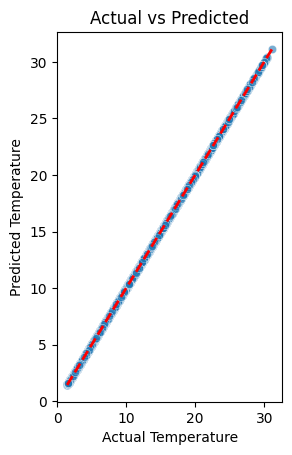

In [14]:
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Identity line
plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')
plt.title('Actual vs Predicted')

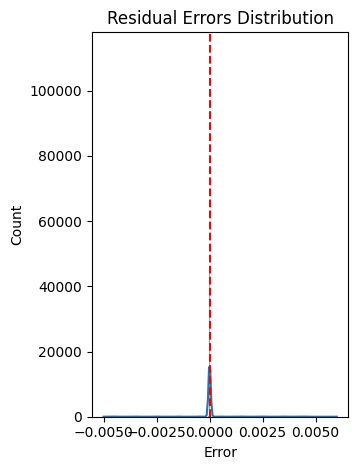

In [15]:
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True)
plt.axvline(0, color='r', linestyle='--')
plt.title('Residual Errors Distribution')
plt.xlabel('Error')

plt.tight_layout()
plt.show()

In [16]:
print("\n--- Model Optimization ---")
selector = SelectKBest(score_func=f_regression, k=5) # Select top 5 features
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_selected, y_train)
y_pred_ridge = ridge_model.predict(X_test_selected)
print(f"Ridge RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.4f}")


--- Model Optimization ---
Ridge RMSE: 0.0006


In [17]:
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_selected, y_train)
y_pred_lasso = lasso_model.predict(X_test_selected)
print(f"Lasso RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):.4f}")

Lasso RMSE: 0.0999


SCENARIO : 2
Classify whether LIC stock price will increase (1) or decrease (0) based on historical data. 

In [18]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk("C:\\Users\\Rithesh\\Downloads\\archive (3)"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

C:\Users\Rithesh\Downloads\archive (3)\LICI - 10 minute data.csv
C:\Users\Rithesh\Downloads\archive (3)\LICI - 3 minute data.csv
C:\Users\Rithesh\Downloads\archive (3)\LICI - 5 minute data.csv
C:\Users\Rithesh\Downloads\archive (3)\LICI - Daily data.csv
C:\Users\Rithesh\Downloads\archive (3)\LICI - minute ata.csv


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,LogisticRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score,recall_score,precision_score,accuracy_score,f1_score,confusion_matrix,ConfusionMatrixDisplay,roc_curve,auc

In [20]:
df=pd.read_csv("C:\\Users\\Rithesh\\Downloads\\archive (3)\\LICI - 10 minute data.csv")
df.head()

,date,open,high,low,close,volume
0,2022-05-17 09:35:00+05:30,872.00,872.00,872.0,872.00,3759243
1,2022-05-17 09:45:00+05:30,872.00,872.00,872.0,872.00,0
2,2022-05-17 09:55:00+05:30,872.00,918.10,862.0,902.80,12449251
3,2022-05-17 10:05:00+05:30,902.45,908.95,896.0,902.15,5237329
4,2022-05-17 10:15:00+05:30,902.30,905.00,900.0,903.85,1820317


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3684 entries, 0 to 3683
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    3684 non-null   str    
 1   open    3684 non-null   float64
 2   high    3684 non-null   float64
 3   low     3684 non-null   float64
 4   close   3684 non-null   float64
 5   volume  3684 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 172.8 KB


In [22]:
df.isnull().sum()

date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

In [23]:
df['Target'] = (df['close'].shift(-1) > df['close']).astype(int)
df_model = df.drop(['date'], axis=1).dropna()

X = df_model.drop('Target', axis=1)
y = df_model['Target']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
# Train Logistic Regression
model = LogisticRegression(C=100, penalty='l2', solver='liblinear', max_iter=5000)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Metrics
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")

Accuracy:  0.5889
Precision: 0.8667
Recall:    0.0414
F1-Score:  0.0790


C:\Users\Rithesh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Text(0.5, 1.0, 'Confusion Matrix')

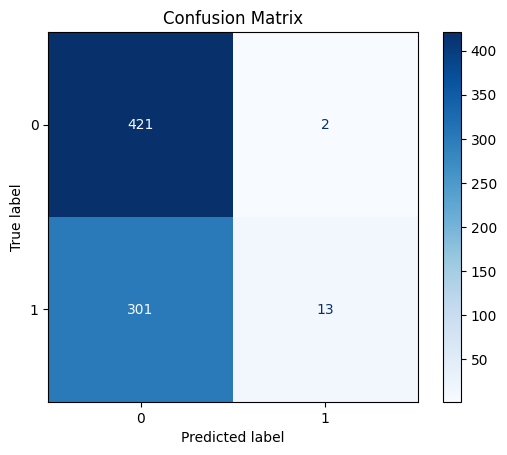

In [26]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")

Text(0.5, 1.0, 'Receiver Operating Characteristic')

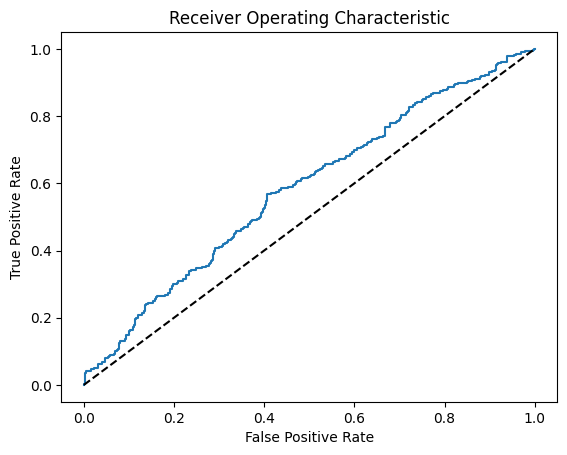

In [27]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')

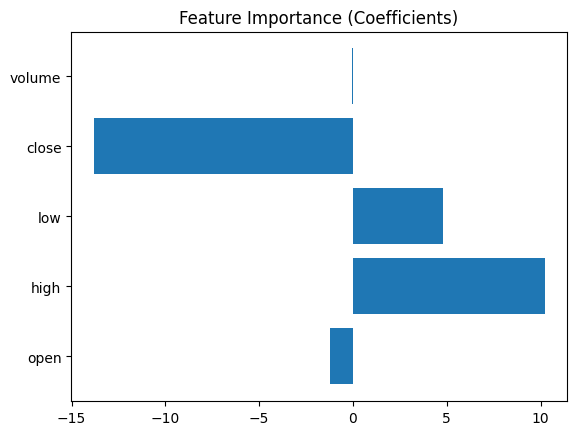

In [28]:
importance = model.coef_[0]
features = X.columns
plt.barh(features, importance)
plt.title("Feature Importance (Coefficients)")
plt.show()

In [32]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'] 
}

grid_search = GridSearchCV(LogisticRegression(max_iter=5000), param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")




Best Parameters: {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
